In [10]:
from sympy import *
import numpy as np


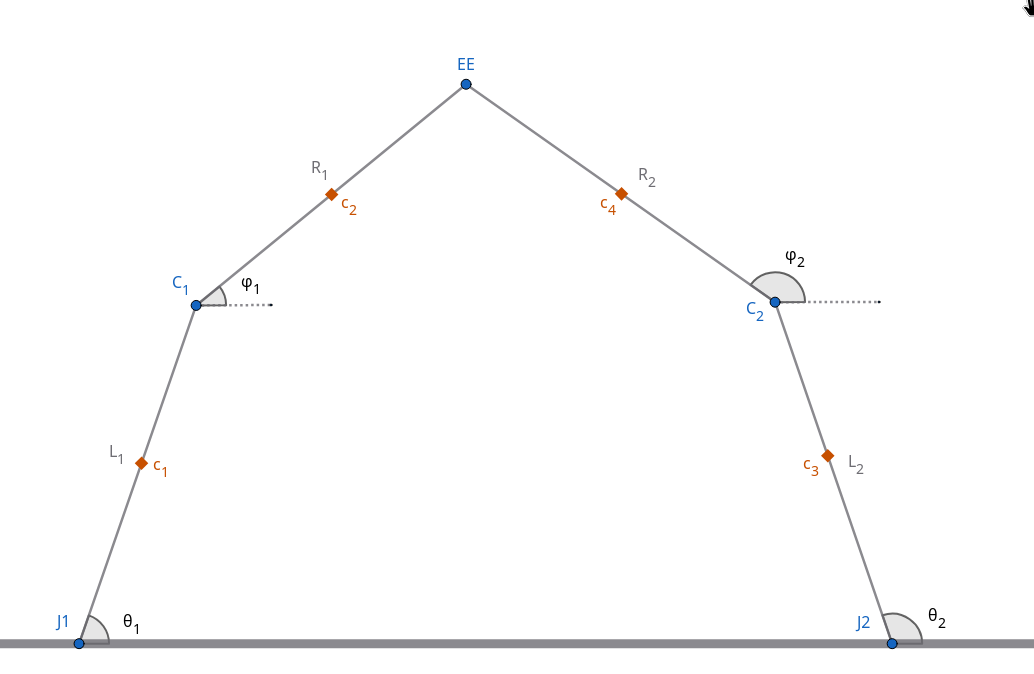

The COM of each links are,
$$
\begin{align*}
C_1 &= \frac{l}{2} \begin{bmatrix}\cos{\theta_1} \\ \sin{\theta_1}\end{bmatrix} \\
C_2 &= \begin{bmatrix}l\cos{\theta_1} + \frac{r}{2}\cos{\phi_1} \\ l\sin{\theta_1} + \frac{r}{2}\sin{\phi_1}\end{bmatrix} \\
C_3 &= \frac{l}{2} \begin{bmatrix}\frac{2l_0}{l} + \cos{\theta_2} \\ \sin{\theta_2}\end{bmatrix} \\
C_4 &= \begin{bmatrix}l_0 + l\cos{\theta_2} + \frac{r}{2}\cos{\phi_2} \\ l\sin{\theta_2} + \frac{r}{2}\sin{\phi_2}\end{bmatrix}
\end{align*}
$$

And the loop closure equations
$$
\begin{align*}
l\cos{\theta_1} + r\cos{\phi_1} &= l_0 + l\cos{\theta_2} + r\cos{\phi_2}, \\
l\sin{\theta_1} + r\sin{\phi_1} &= l\sin{\theta_2} + r\cos{\phi_2}
\end{align*}
$$

Need to calculate $L=T-U$, where $T$ is the Kinetic energy and $U$ is the potential energy.

In [2]:
t = symbols('t')
th1 = Function('th1')(t)
th2 = Function('th2')(t)
ph1 = Function('ph1')(t)
ph2 = Function('ph2')(t)

l, l0, r = symbols('l l0 r', positive=True)

## Kinetic Energy

The time derivative of the loop closure equations
$$
r\begin{bmatrix}
\sin{\phi_1} & -\sin{\phi_2} \\
\cos{\phi_1} & -\cos{\phi_2}
\end{bmatrix} \begin{bmatrix} \dot{\phi_1} \\ \dot{\phi_2} \end{bmatrix} =
l\begin{bmatrix}
-\sin{\theta_1} & \sin{\theta_2} \\
-\cos{\theta_1} & \cos{\theta_2}
\end{bmatrix} \begin{bmatrix} \dot{\theta_1} \\ \dot{\theta_2} \end{bmatrix}
$$

In [3]:
A = Matrix([
    [sin(ph1), -sin(ph2)],
    [cos(ph1), -cos(ph2)]
])

B = Matrix([
    [-sin(th1), sin(th2)],
    [-cos(th1), cos(th2)]
])

J = (l/r) * A.inv() @ B # Jacobian = A^-1 B

To calculate the Velocity for the links of the left side,
$$
\begin{align*}
V_1 &= \frac{l}{2}\begin{bmatrix}-\sin{\theta_1} \\ \cos{\theta_1} \end{bmatrix} \dot{\theta_1} \\
V_2 &= l\begin{bmatrix}-\sin{\theta_1} \\ \cos{\theta_1} \end{bmatrix} \dot{\theta_1} + \frac{r}{2}\begin{bmatrix}-\sin{\phi_1} \\ \cos{\phi_1} \end{bmatrix} J_1 \begin{bmatrix}\dot{\theta_1} & \dot{\theta_2}\end{bmatrix} 
\end{align*}
$$
Similarly for the Velocity for the links of the right side,
$$
\begin{align*}
V_3 &= \frac{l}{2}\begin{bmatrix}-\sin{\theta_2} \\ \cos{\theta_2} \end{bmatrix} \dot{\theta_2} \\
V_4 &= l\begin{bmatrix}-\sin{\theta_2} \\ \cos{\theta_2} \end{bmatrix} \dot{\theta_2} + \frac{r}{2}\begin{bmatrix}-\sin{\phi_2} \\ \cos{\phi_2} \end{bmatrix} J_2 \begin{bmatrix}\dot{\theta_1} & \dot{\theta_2}\end{bmatrix} 
\end{align*}
$$

This happens because $\phi_i$ are constrained by both the value of $\theta_i$ therefore, $\dot{\phi_i} = f(\dot{\theta_1}, \dot{\theta_2})$

In [4]:
# Time Derivatives = Velocity
dth1 = diff(th1, t)
dth2 = diff(th2, t)
dq = Matrix([dth1, dth2])

v1 = Rational(1,2)*l*Matrix([-sin(th1), cos(th1)]) * dth1
v2 = 2*v1 + Rational(1,2)*r*Matrix([-sin(ph1), cos(ph1)]) * J.row(0).dot(dq)

v3 = Rational(1,2)*l*Matrix([-sin(th2), cos(th2)]) * dth2
v4 = 2*v3 + Rational(1,2)*r*Matrix([-sin(ph2), cos(ph2)]) * J.row(1).dot(dq)

To find the final Kinetic energy,
$$
T = \frac{1}{2}\sum{m_i v_i^2}
$$

In [5]:
m1, m2, m3, m4 = symbols('m1 m2 m3 m4', positive=True)
masses = [m1,m2,m3,m4]
vels = [v1,v2,v3,v4]

T = Rational(1,2) * sum(m*v.dot(v) for m, v in zip(masses, vels))

## Potential Energy

The end effector will be planner which makes the whole mechanism planner perpendicular to gravity.
The first two cranker will have same height of $h$ starting from the servos, whilst the two coupler will have different height of $h1$ and $h2$ to match the offset of the end effector position in $z$-axis.

But these heights do not depend on the inpendent variables $\theta_1$ and $\theta_2$.

## Euler-Lagrange Equation of Motion

So our final form becomes $L = T$,

By EL EOM,
$$
\frac{d}{dt}\begin{pmatrix}\frac{\partial L}{\partial\dot{q_i}}\end{pmatrix} -\frac{\partial L}{\partial q_i} = Q_i
$$

Where $Q_i$ is the external force applied on the system, for this case $Q_i = \tau_i$ trivially exerted by the mounted actuators.

Consequently, two equations yield,
$$
\begin{align*}
\frac{d}{dt}\begin{pmatrix}\frac{\partial T}{\partial\dot{\theta_1}}\end{pmatrix} -\frac{\partial T}{\partial \theta_1} = \tau_1 \\
\frac{d}{dt}\begin{pmatrix}\frac{\partial T}{\partial\dot{\theta_2}}\end{pmatrix} -\frac{\partial T}{\partial \theta_2} = \tau_2
\end{align*}
$$

In [6]:
tau1 = diff( diff(T, dth1), t ) - diff(T, th1)
tau2 = diff( diff(T, dth2), t ) - diff(T, th2)

In [8]:
tau1 = trigsimp(tau1)
tau2 = trigsimp(tau2)

KeyboardInterrupt: 

## Final Measurements

In [11]:
geom = {
    l0: 1,
    l : 1,
    r : 1,
} # mm

mass = {
    m1: 1,  # mass of cranker 1
    m2: 1,  # mass of coupler 1
    m3: 1,  # mass of cranker 2
    m4: 1   # mass of coupler 2
} # gm

th_range = np.linspace(-np.pi, np.pi, 200)